In [210]:
import numpy as np 
import random
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [211]:
import os

# Lets count the amount of sessions and individual files we have and while doing so, check that our paths are correct. 
data_dir = "../RDRD_dataset" 
subject_type = ["Cars", "Drones", "People"]
frames_per_sample = 3
SEED = 42
LR = 1e-3
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
BATCH_SIZE = 32
EPOCHS = 60

# Check data_dir is there, if so, for each subject type (class), check the path data_dir/subject_type
assert os.path.isdir(data_dir), f"data directory is not present at: {data_dir}"

for subject in subject_type:
    # create data_path to directory containing all sessions
    data_path = os.path.join(data_dir, subject)
    assert os.path.isdir(data_path), f"data folder is not present at: {data_path}"
    # Create list of all the session folders to count
    sessions = [session_file for session_file in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, session_file)) ]
    # Count all the csv files in every session and prnt number of sessions and number of total files
    num_files = sum(1 for _, _, files in os.walk(data_path) for f in files if f.lower().endswith(".csv"))   
    print(f"{subject}: has {len(sessions)} session folders and {num_files} csv files total")

Cars: has 27 session folders and 5723 csv files total
Drones: has 21 session folders and 5065 csv files total
People: has 32 session folders and 6700 csv files total


In [212]:
# set random seeds for reproduciblity. 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


### The frames and are labeled numerically 001.csv, 002.csv in order. 
* We will create windows where each window contains frames_per_window frames.
     * For example, if frames_per_window = 3: w_1= [f1 f2 f3].
     *  Windows will overlap, so w_2= [f2 f3 f4], ("stride" of 1 between windows.)
* To reproduce paper, we will let frames_per_window = 3 them in a torch tensor as channels. So each window sample will be shape (3, 11, 61) where each frame is CFAR + trimmed 11x61 range-doppler matrix.

We will split at the session level. This is because our windows overlap (as described above), meaning leakage will happen if say there are two overlapping (share frames) windows and one ends up in the train dataset, and another in the test or val. We'll organize our data in a dictionary, give each file a session_id to track its session, and track its label. 


## Create Windows

In [213]:
def get_label_num(fname: str) -> tuple[int,str]:
    """ grab number corresponding to file name. This works because files are in format e.g. '001.csv', 
        where sequence of positive integers in file title corresponds to order it was recorded (001 was recorded first, then 002, etc).
        Args:
            fname (str): The name of file to parse
        Returns: 
            tuple[int,str]: A tuple containing:
            - int: extracted file number (0 if missing).
            - str: Original file name. 
    """
    # store all sequences of one or more digits as a list, pick the first (should be just one).
    num_label = re.findall(r'\d+',fname)
    return (int(num_label[0]) if num_label else 0, fname) 

# Create a list of dictionaries. For each class name, for each session, list all paths to files. 
# recall subject_type = ["Cars", "Drones", "People"], data_dir = "RDRD_dataset" 

sessions_list = []
for class_name in subject_type: 
    class_dir = os.path.join(data_dir, class_name)
    
    for session_name in sorted(os.listdir(class_dir)): 
        session_dir = os.path.join(class_dir,session_name)
        
        if not os.path.isdir(session_dir):
            continue
        csv_files_list = [f for f in os.listdir(session_dir) if f.lower().endswith('.csv')]
        csv_files_list = sorted(csv_files_list, key = get_label_num)
        file_path_list = [os.path.join(session_dir, file) for file in csv_files_list]
        
        if len(file_path_list) >= frames_per_sample: 
            sessions_list.append({"class": class_name, "session_id": session_name, "paths": file_path_list })
        else: 
            print(f"Skipped {class_name}/{session_name}, only {len(csv_files_list)} frames < frames per sample {frames_per_sample}" )
print(f"Total usable sessions: {len(sessions_list)}")
            
        
# Create a dic of session_id by class so we can begin to stratify our data by class. 
# (list_of_N_paths, label_idx, session_id)
class_to_idx = {cname: i for i, cname in enumerate(subject_type)}
print(class_to_idx)
all_windows = []

# since we are sliding our windows over by 1 each time, if you have len(files) number of files, 
# that gives len(files) - frames_per_sample + 1 number of windows. 
for sess_id, sess in enumerate(sessions_list):
    label = class_to_idx[sess["class"]]
    files = sess["paths"]
    
    for start in range(len(files)- frames_per_sample +1):
        window_paths = files[start:start+frames_per_sample] 
        all_windows.append((window_paths, label, sess_id))
        
print(f"Total windowed samples (before split): {len(all_windows)}")
print(all_windows[0])


Total usable sessions: 80
{'Cars': 0, 'Drones': 1, 'People': 2}
Total windowed samples (before split): 17325
(['../RDRD_dataset/Cars/13-13/001.csv', '../RDRD_dataset/Cars/13-13/002.csv', '../RDRD_dataset/Cars/13-13/003.csv'], 0, 0)


## Create splits by sessions, with roughly same class balance

In [214]:
 # Want to have the same representation of class in each of train/test/val. 
 # So for each class, assign 15% of sessions to val, 15% to test, and 70% to train. So after one class, each set of session ids assigned 
#should look like :
    # val: [0,1,2,3]
    # test: [4:8]= [4,5,6,7]
    # train: [8,9,10,.....]
# however, we want to randomize the sessions that are assigned so it would look more like 
 # val: [45,3,69,4] 
    # test: [9,30,5,10]
    # train: [11,42,23,.....]
# and then these will grow as you assign for the other classes



rng = random.Random(SEED)

sessions_by_class = {c: [] for c in subject_type}
for sess_id, sess in enumerate(sessions_list):
    sessions_by_class[sess["class"]].append(sess_id)

train_sess_ids, val_sess_ids, test_sess_ids = set(), set(), set()
for cname, ids in sessions_by_class.items():
    ids = ids[:]
    rng.shuffle(ids)
    n = len(ids)

    n_val = max(1, int(n*VAL_SPLIT))
    n_test = max(1, int(n*TEST_SPLIT))
 
    val_sess_ids.update(ids[:n_val])
    test_sess_ids.update(ids[n_val:n_val+n_test])
    train_sess_ids.update(ids[n_val+n_test:])
    print(f"{cname}: {n} sessions -> train {n-n_val-n_test}, val {n_val}, test {n_test}")

    #print(f"these are the val ids: {val_sess_ids}")
    #print(f"these are the test ids: {test_sess_ids}")
    #print(f"these are the train ids: {train_sess_ids}")
    #print(f"checking they are disjoint, their intersection is:{val_sess_ids & test_sess_ids & train_sess_ids} ")


train_windows = [w for w in all_windows if w[2] in train_sess_ids ]
test_windows = [w for w in all_windows if w[2] in test_sess_ids ]
val_windows = [w for w in all_windows if w[2] in val_sess_ids ]
print(f"Windowed samples -> train: {len(train_windows)} val: {len(val_windows)}, test: {len(test_windows)}")

Cars: 27 sessions -> train 19, val 4, test 4
Drones: 21 sessions -> train 15, val 3, test 3
People: 32 sessions -> train 24, val 4, test 4
Windowed samples -> train: 13414 val: 1983, test: 1928


In [215]:
print(train_windows[0])

(['../RDRD_dataset/Cars/13-13/001.csv', '../RDRD_dataset/Cars/13-13/002.csv', '../RDRD_dataset/Cars/13-13/003.csv'], 0, 0)


In [216]:
class RDRD_win_data(Dataset):
    """Windows of consecutive radar frames. Each CSV is parsed and normalized once, then cached.
    windows: list of (window_paths, label, sess_id), where window_paths holds
    frames_per_sample CSV paths in order (['RDRD_dataset/Cars/13-13/001.csv', '.../002.csv', '.../003.csv'], 0, 0).
    Each sample is stacked to shape (frames_per_sample, H, W).
    """

    def __init__(self, windows, norm_stats):
        self.windows = windows
        self.mean, self.std = norm_stats

        unique_paths = {fp for paths,_ ,_ in windows for fp in paths}
        self.cache = {fp: ((self._load_matrix(fp) - self.mean) / self.std).astype(np.float32)
                    for fp in unique_paths}
        
    def __len__(self):
        return len(self.windows)
        
    @staticmethod
    def _load_matrix(fp):
        return np.loadtxt(fp, dtype = np.float32 , delimiter = ",")

    def __getitem__(self, idx):
        paths, label ,_ = self.windows[idx]
        stacked = np.stack([self.cache[fp] for fp in paths], axis = 0)
        tensor = torch.from_numpy(stacked)
        return tensor, label


In [217]:
# Determine train-set normalization stats
# Compute mean and std over a sample of frames in train split
# grab paths from train_windows, add to sample_paths
# shuffle paths and sample (we'll set to grab the first 2k frames for reproducability speed. Here we don't even had 2k frames)
# load data using np.loadtext and append, stack along channel axis, get global mean, global std

sample_vals = []
sample_paths = set()
# print(train_windows[0])
#(['RDRD_dataset/Cars/13-13/001.csv', 'RDRD_dataset/Cars/13-13/002.csv', 'RDRD_dataset/Cars/13-13/003.csv'], 0, 0)

for paths, _ , _ in train_windows:
    sample_paths.update(paths)
    
sample_paths = list(sample_paths)
rng.shuffle(sample_paths)

for fp in sample_paths[:2000]:
    sample_vals.append(np.loadtxt(fp, dtype = np.float32, delimiter = ","))
    
sample_vals = np.stack(sample_vals, axis = 0)
data_mean, data_std = float(sample_vals.mean()), float(sample_vals.std())
print(f"Train mean: {data_mean} | Train std: {data_std}")

Train mean: -111.76591491699219 | Train std: 9.704228401184082


In [218]:
# class RDRD_win_data(Dataset):
#    def __init__(self, windows, norm_stats)

train_ds = RDRD_win_data(train_windows, (data_mean, data_std))
test_ds = RDRD_win_data(test_windows, (data_mean, data_std))
val_ds = RDRD_win_data(val_windows, (data_mean, data_std))


train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False)

 Each tensor mats has shape (B, frames_per_sample, H, W): torch.Size([32, 3, 11, 61])


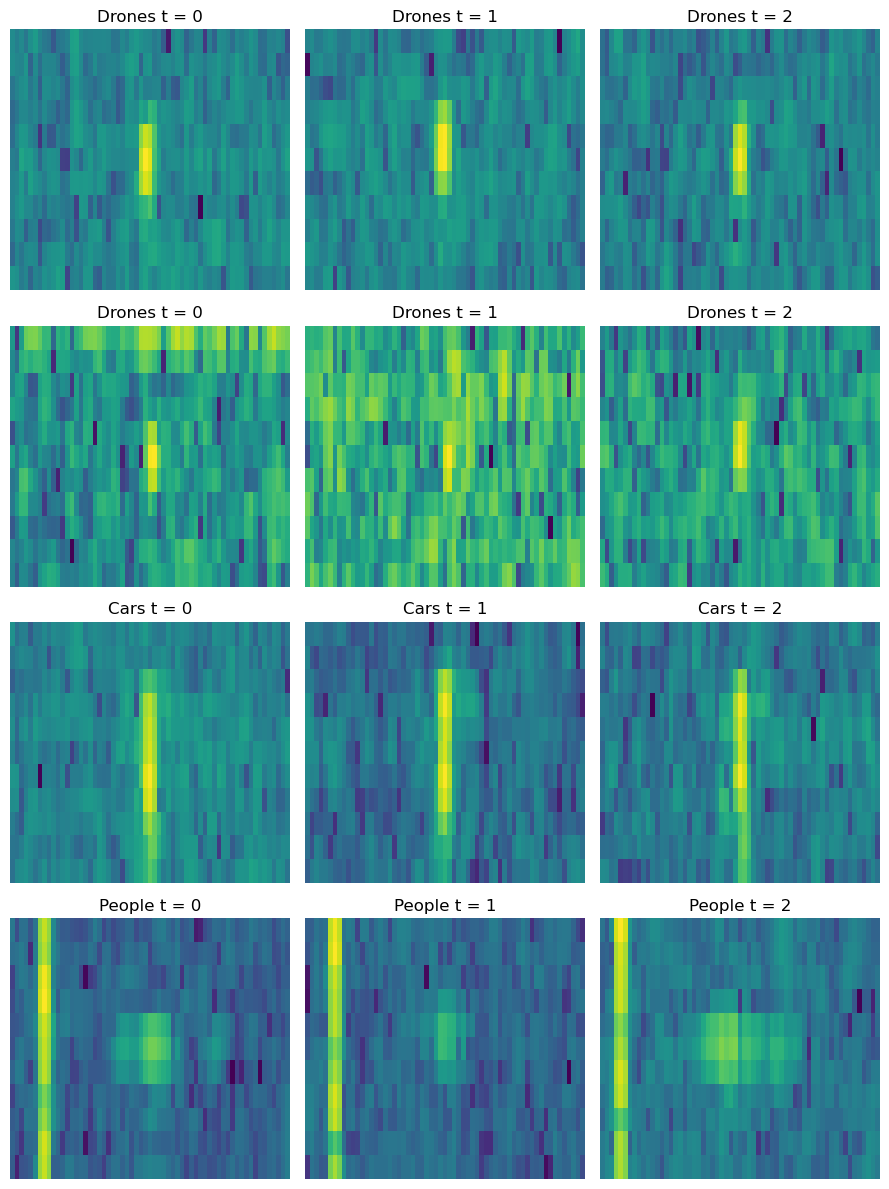

In [236]:
# Visualize some training frames
# limit to 4 batches
mats, labels = next(iter(train_loader))
print(f" Each tensor mats has shape (B, frames_per_sample, H, W): {mats.shape}")
n_show = min(4, mats.size(0))

# Build n_show x frames_per_sample axes
# Numpy/Matplotlib needs data on cpu. For each frame, detach, attach to cpu, cast to numpy array, reverse normalization
# for 2D image display can use axes.imshow
# for title, convert numerical 0,1,2 to Cars, People, Drones, recall subject_type = ["Cars", "Drones", "People"], 

fig, axes = plt.subplots(n_show, frames_per_sample, figsize=(3 * frames_per_sample, 3 * n_show))
if n_show == 1:
    axes = axes[None, :]
    
for i in range(n_show):
    for t in range(frames_per_sample):
        mat = mats[i,t].detach().cpu().numpy()* data_std + data_mean
        axes[i,t].imshow(mat, colorizer = "viridis", aspect = "auto")
        axes[i,t].set_title(f"{subject_type[labels[i]]} t = {t}")
        axes[i,t].axis("off")
        
plt.tight_layout()
plt.show()

## Assessing and Addressing Class Imbalance in Training Set 

In [220]:
# Count the windows in our train set, see how they are stratified by class
from collections import Counter

train_labels = [w[1] for w in train_windows]
class_count = Counter(train_labels)
class_count_names = {subject_type[k]:v for k,v in class_count.items()}


print(f"There are a total of {len(train_labels)} windows in our train set, broken down by class as\n {class_count_names}")
print(f"Just double-checking {len(train_labels)} = {sum(class_count.values())}" )

# Address weight imbalance by calculating a new weights
# Assign weights to our device (have to be on same as model)
# pass our tensor of weights to our loss function nn.CrossEntropyLoss(weight = our tensor)


There are a total of 13414 windows in our train set, broken down by class as
 {'Cars': 4263, 'Drones': 3954, 'People': 5197}
Just double-checking 13414 = 13414


## Paper's Approach to Class balancing: Inverse-frequency weighting
The paper implements inverse-frequency weighting where we weigh class c by $w_c = 1/n_c$ where $n_c$ is the frequency of class c in your training set. 


In [221]:
class_weights = torch.tensor([len(train_labels)/class_count.get(i,1) for i in range(len(subject_type))],dtype = torch.float32, device = device)
# normalize (divide by sum of weights), make them sum to number of classes (multiply by # of classes)
class_weights = class_weights/class_weights.sum()*len(subject_type)
print(class_weights)

tensor([1.0350, 1.1159, 0.8490], device='mps:0')


## Our approach: Class-balanced loss. [Cui, et al.](https://www.computer.org/csdl/proceedings-article/cvpr/2019/329300j260/1gyrmDpnl72) 

We introduce the hyperparameter $\beta = (N-1)/N$ where N is either total training samples or number of samples in the largest class. Instead of weighting by $1/ n_c$, we weight by a fixed $1/E(n_c)$ where $E(n_c) = (1-\beta)/(1-\beta^{n_c})$

In [222]:
total_samples = len(train_labels)
beta = (total_samples -1)/ total_samples
count_tensor = torch.tensor([class_count.get(i,1) for i in range(len(subject_type))], dtype = torch.float32, device = device)
den_tensor = 1.0 - torch.pow(beta, count_tensor)
class_weights = (1.0 - beta)/den_tensor
class_weights = class_weights/class_weights.sum()*len(subject_type)
print("Counts:", count_tensor.tolist())
print("Weights:", class_weights.tolist())
print(class_weights)

Counts: [4263.0, 3954.0, 5197.0]
Weights: [1.0294981002807617, 1.0978827476501465, 0.8726191520690918]
tensor([1.0295, 1.0979, 0.8726], device='mps:0')


## Model

In [223]:
class RDRD_CNN(nn.Module):
    def __init__(self, num_classes, in_channels, in_shape):
        super().__init__()
        h,w = in_shape 
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, out_channels = 32, kernel_size = 3, padding = 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size = (1,2)),
            nn.Conv2d(64, 128, kernel_size = 3, padding = 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size = (1,2)),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, h,w)
            flat_dim = self.features(dummy).numel()
            
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),        
        )
        
    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

In [224]:
model =  RDRD_CNN(num_classes = len(subject_type), in_channels = frames_per_sample, in_shape = (11,61)).to(device)
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {train_params}" )

Trainable parameters: 2797571


In [225]:
criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = optim.Adam(model.parameters(), lr = LR, weight_decay = 1e-4)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 4)

In [229]:
class Trainer:
    """Runs train/val epochs with early stopping and restores the best-validation weights."""
    def __init__(self,model, train_loader, val_loader, optimizer, criterion, lr_scheduler, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        
    def epoch_run(self, train_mode = True):
        """Run one epoch over the train or val loader and return (avg loss, accuracy)."""
        total_loss, correct, total = 0.0, 0, 0
        
        if train_mode:
            self.model.train() 
        else:
            self.model.eval()
        with torch.set_grad_enabled(train_mode):
            loader = self.train_loader if train_mode else self.val_loader
            for (mats, labels) in loader:
                mats, labels = mats.to(self.device), labels.to(self.device)
                
                if train_mode:
                    self.optimizer.zero_grad()
                outputs = self.model(mats)
                loss = self.criterion(outputs, labels)
                
                if train_mode:
                    loss.backward()
                    self.optimizer.step()
                total_loss += loss.item()*mats.size(0)
                preds = outputs.argmax(dim = 1)
                correct += (preds == labels).sum().item()
                total+= mats.size(0)
                
        return total_loss/total, correct/total
        
    def fit(self, EPOCHS = 50, patience = 10):
        """Train for up to EPOCHS, stopping early after 'patience' epochs elapse without val accuracy improvement.
        Returns the per epoch history dict."""
        history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
        best_val_acc = 0.0
        best_state = None
        patience_counter = 0
        
        for epoch in range(1, EPOCHS+1):
            tr_loss, tr_acc = self.epoch_run(train_mode = True)
            val_loss, val_acc = self.epoch_run(train_mode = False)
            self.lr_scheduler.step(val_loss)
            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss {tr_loss:.4f}, Train Acc {tr_acc:.4f}  | Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu().clone() for k,v in self.model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter+= 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs).")
                    break
                    
        if best_state is not None:
            self.model.load_state_dict(best_state)
            
        print(f"\nBest validation accuracy: {best_val_acc:.3f}")
        
        return history
        
    def evaluate(self, loader):
        """Return loss, accuracy, and all predictions and labels for the loader set"""
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [],[]
        
        with torch.no_grad():
            for mats, labels in loader:
                mats, labels = mats.to(self.device), labels.to(self.device)
                outputs = self.model(mats)
                loss = self.criterion(outputs, labels)
                preds = outputs.argmax(axis = 1)
                total_loss += loss.item()*mats.size(0)
                correct+= (preds == labels).sum().item()
                total+= mats.size(0)
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        return ((total_loss/total), correct/total, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy())

In [227]:
trainer = Trainer(model, train_loader, val_loader, optimizer, criterion, lr_scheduler, device)
history = trainer.fit(EPOCHS=50, patience=10)

test_loss, test_acc, test_preds, test_labels = trainer.evaluate(test_loader)
print(f"Test loss {test_loss:.4f} | Test Acc {test_acc:.4f}")

Epoch  1/50 | Train Loss 0.3284, Train Acc 0.9021  | Val Loss 0.0814, Val Acc 0.9702
Epoch  2/50 | Train Loss 0.1193, Train Acc 0.9556  | Val Loss 0.0714, Val Acc 0.9758
Epoch  3/50 | Train Loss 0.1016, Train Acc 0.9654  | Val Loss 0.0767, Val Acc 0.9788
Epoch  4/50 | Train Loss 0.0800, Train Acc 0.9738  | Val Loss 0.1328, Val Acc 0.9667
Epoch  5/50 | Train Loss 0.0747, Train Acc 0.9750  | Val Loss 0.0785, Val Acc 0.9672
Epoch  6/50 | Train Loss 0.0712, Train Acc 0.9774  | Val Loss 0.0901, Val Acc 0.9763
Epoch  7/50 | Train Loss 0.0697, Train Acc 0.9782  | Val Loss 0.0679, Val Acc 0.9798
Epoch  8/50 | Train Loss 0.0484, Train Acc 0.9837  | Val Loss 0.0739, Val Acc 0.9768
Epoch  9/50 | Train Loss 0.0525, Train Acc 0.9826  | Val Loss 0.0909, Val Acc 0.9728
Epoch 10/50 | Train Loss 0.0455, Train Acc 0.9855  | Val Loss 0.1226, Val Acc 0.9677
Epoch 11/50 | Train Loss 0.0457, Train Acc 0.9861  | Val Loss 0.0851, Val Acc 0.9702
Epoch 12/50 | Train Loss 0.0404, Train Acc 0.9869  | Val Loss 0.1

In [228]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_labels, test_preds, target_names=subject_type))
print(confusion_matrix(test_labels, test_preds))

              precision    recall  f1-score   support

        Cars       0.97      0.97      0.97       719
      Drones       0.95      0.97      0.96       540
      People       0.99      0.97      0.98       669

    accuracy                           0.97      1928
   macro avg       0.97      0.97      0.97      1928
weighted avg       0.97      0.97      0.97      1928

[[696  21   2]
 [ 11 526   3]
 [ 10   7 652]]


In [230]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": list(subject_type),
    "num_classes": len(subject_type)
    "target_shape": (11,61),
    "frames_per_sample": frames_per_sample,
    "normalize_mean": data_mean,
    "normalize_std": data_std,
}, "radar_cnn_rdrd.pt")
print("Saved to radar_cnn_rdrd.pt")


Saved to radar_cnn_rdrd.pt
